In [77]:
from radiocovid.core import RadioCovidDataset, RadioCovidDataModule, RadioCovidModule
from radiocovid.core.data import RadioCovidSubset
from torch.utils.data import DataLoader
import torch
from hashlib import sha256
from pathlib import Path
from radiocovid.core.utils import (
    seed_worker,
    get_seeded_generator,
    worker_balanced_n_samples,
)
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import numpy as np
from collections import defaultdict, Counter
import hydra
from hydra import initialize, compose
import torch.nn.functional as F
import cv2
from PIL import Image
from IPython.display import display
from glob import glob
import pandas as pd
import  matplotlib.pyplot as plt

In [2]:
with initialize(
    version_base=None,
    config_path="../radiocovid-core/src/radiocovid/core/configs",
    job_name="test_app",
):
    cfg = compose(config_name="train", overrides=["experiment=train_resnet50_binary", "datamodule.dataset.root=../data/03_inputs"])

In [12]:
model = hydra.utils.instantiate(cfg.module)
ckpt = torch.load("/kaggle/working/sep25_alt1_mle_ds_covid1/logs/train/multiruns/2026-03-09_22-56-17/12/tensorboard/version_0/checkpoints/epoch=4-step=1230.ckpt", map_location="cpu")
model.load_state_dict(ckpt["state_dict"])

<All keys matched successfully>

In [95]:
transforms = hydra.utils.instantiate(cfg.datamodule.dataset.transform)
eval_transforms = hydra.utils.instantiate(cfg.datamodule.eval_transform)

In [54]:
preds = torch.unique(torch.cat([torch.load(f) for f in glob("/kaggle/working/sep25_alt1_mle_ds_covid1/logs/train/multiruns/2026-03-09_22-56-17/12/tensorboard/version_0/*.pt")]), dim=0) 

In [58]:
mnfst = pd.read_parquet("/kaggle/working/sep25_alt1_mle_ds_covid1/data/02_manifests/manifest_ft_full.parquet")

In [59]:
paths = mnfst.image.unique().tolist()

In [60]:
d = {
    int(sha256(Path(path).stem.encode()).hexdigest()[:8], 16): Path(path).stem.split("-")[0]
    for path in paths
}

In [72]:
d_path = {
    int(sha256(Path(path).stem.encode()).hexdigest()[:8], 16): Path(path)
    for path in paths
}

In [76]:
def make_gradcam_heatmap(img_tensor, model, target_layer_name, pred_index=None):   
    # Passer en avant pour obtenir les prédictions et les activations de la couche cible
    def forward_hook(module, input, output):
        model.features = output

    # Enregistrer un hook sur la couche cible pour récupérer ses sorties
    hook = model._modules.get(target_layer_name).register_forward_hook(forward_hook)
    
    # Effectuer une passe avant pour obtenir les sorties du modèle
    output = model(img_tensor)
    
    # Supprimer le hook après avoir récupéré les activations
    hook.remove()

    # Si aucun indice de prédiction n'est fourni, utiliser celui avec la plus haute probabilité
    if pred_index is None:
        pred_index = output.argmax(dim=1).item()
    
    # Valeur de probabilité de la classe
    y = output[0, pred_index]
    
    # Passer en arrière pour obtenir les gradients de la couche cible
    model.zero_grad()  # Remettre à zéro les gradients
    model.features.retain_grad()  # Garder les gradients de la couche cible
    y.backward(retain_graph=True)  # Calculer les gradients par rétropropagation

    # Obtenir les gradients et les activations de la couche cible
    gradients = model.features.grad[0]
    activations = model.features[0]

    # Appliquer un pooling global moyen sur les gradients
    pooled_grads = torch.mean(gradients, dim=[1, 2])

    # Pondérer les activations par les gradients
    for i in range(len(pooled_grads)):
        activations[i, :, :] *= pooled_grads[i]

    # Calculer la heatmap
    heatmap = torch.mean(activations, dim=0).detach().numpy()
    heatmap = np.maximum(heatmap, 0)  # Ne conserver que les valeurs positives
    heatmap /= np.max(heatmap)  # Normaliser la heatmap

    return heatmap

prédiction :  tensor(0)  Label :  Normal


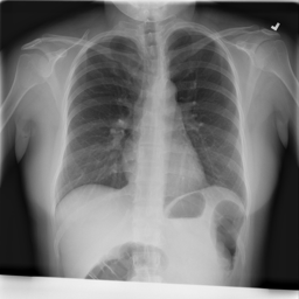

In [136]:
IDX = 6
IMAGE= d_path[int(preds[IDX, 0])]
img = Image.open(IMAGE)
print("prédiction : ", preds[IDX, 1:3].argmax(), " Label : ", d_path[int(preds[IDX, 0])].stem.split("-")[0])
display(img)

In [137]:
imgt = transforms(img)
imgt = eval_transforms(imgt)
model.eval()
with torch.inference_mode():
    out = model(imgt.unsqueeze(0))
out.detach().softmax(dim=1)

tensor([[0.7064, 0.2936]])

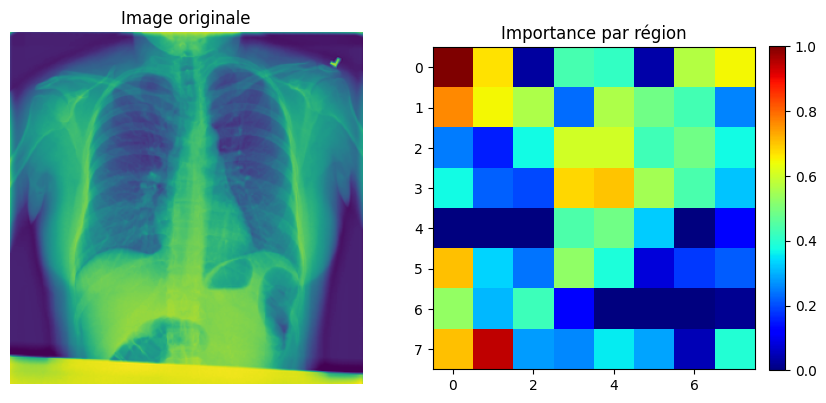

In [139]:
TARGET_LAYER =  'layer4'
heatmap= make_gradcam_heatmap(imgt.unsqueeze(0), model.net, TARGET_LAYER, pred_index=0)
# Visualiser les résultats
plt.figure(figsize=(10, 7))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Image originale")
plt.axis("off")

# Heatmap
plt.subplot(1, 2, 2)
hm = plt.imshow(heatmap, cmap="jet")
plt.title("Importance par région")

# Heatmap scale
plt.colorbar(hm, fraction=0.046, pad=0.04)

plt.show()